# Module 5 Lab 3

At this point, the data base has been cleaned in my Module 5 Lab2. I will coppy and paste my Lab 2 cleaning steps again here.

**Summary of changes to dataset**

The original data set (originaldf) was 1000 rows/series and 11 columns.
The final modified dataset (mod_df) is 944 rows/series and 10 columns.

Housing Type: Housing type had 944 non-null values and 56 null values (these rows are also missing recent move and number of vehicles, as seen on heatmap). 
+ Since we are sorting our data based on housing type, all 56 NA rows were dropped. The original dataset will be saved as originaldf. The working data frame at this point is called df.

Income: We have a negative minimum income value which needs to be investigated. The max is not outside expected range, there is a right skew and that is normal for income data.
+ The negative income was -8700. The choices were delete, change to 0 (a not employed person)or switched to positive. The value was switched to +8700 after confiming that the majority of the not employed had an income (not 0) and 8700 was within the range of not employed income (0 to 175000).

Age: The minimum age is zero and needs to be investigated. The maximum age is 146 and cannot be.
+ The age minimum was determined to be 19 and the three rows with age 0 were anonymous. There were 8 ages above 93. 93 was considered to be the oldest, as there were 5 of them and the other 8 were between 113 and 146. In all cases, the mean age for the housing type age was input as the missing age. Note: this does bias the data towards the mean. These 8 out of 944 values are biased toward the mean. 

Is Employed: We are missing 328 "is employed" boolean responses. As we are making a bar graph with the categories of housing type, a boolean response is not an appropriate graphing partner. This column was considered extraneous for our purposes and excluded in a new data set called mod_df with 944 rows and 10 columns.

**Any thing that needs to be updated for this new assignment?**

Deleting the column "is employed, still stands. We will not be using this data, but the other data is useful to us. 

The one out of 944 income values that needed addressing still stands and does not impact the data greatly.

The 11 out of 944 assumptions for age, I will still stand by. Although, the 11 changes do potetentially bias the data toward the mean as the mean income for each housing type was used.

**Must replace "." in column names with "_" due to coding errors.**


In [1]:
#import UNCLEANED data (df) base and run correlations
import numpy as np
import seaborn as sns
import pandas as pd
import scipy
originaldf = pd.read_csv("custdata.tsv", sep="\t")
df = originaldf
df.columns = df.columns.str.replace('.', '_')

<Axes: >

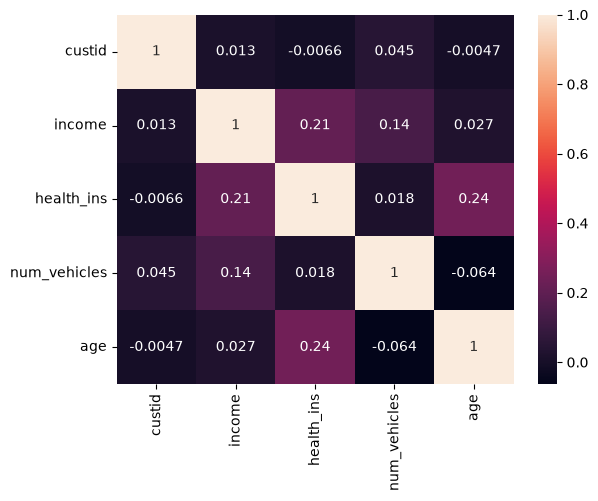

In [2]:
#Seaborn heat map of UNCLEANED data
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [3]:
#Calculate the 3 way comparison of age, income, number of vehicles using ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Fit the model
model = ols('age ~ income + num_vehicles', data=df).fit()

#Perform ANOVA
anova_result = sm.stats.anova_lm(model, typ=2)

#Print ANOVA result
print("Correlations of Uncleaned Data")
print(anova_result)


Correlations of Uncleaned Data
                     sum_sq     df         F    PR(>F)
income           221.060941    1.0  0.651973  0.419612
num_vehicles    1426.308123    1.0  4.206599  0.040543
Residual      319059.666448  941.0       NaN       NaN


# Import Clean database from my Module 5.2

In [4]:
import pandas as pd
df_mod = pd.read_csv("df_mod.csv")
df_mod.columns = df_mod.columns.str.replace('.', '_')

In [5]:
df_mod.shape

(944, 10)

In [6]:
df_mod.head()

,custid,sex,income,marital_stat,health_ins,housing_type,recent_move,num_vehicles,age,state_of_res
0,2068,F,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [7]:
df_mod.info()

<class 'pandas.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        944 non-null    int64  
 1   sex           944 non-null    str    
 2   income        944 non-null    int64  
 3   marital_stat  944 non-null    str    
 4   health_ins    944 non-null    bool   
 5   housing_type  944 non-null    str    
 6   recent_move   944 non-null    bool   
 7   num_vehicles  944 non-null    float64
 8   age           944 non-null    float64
 9   state_of_res  944 non-null    str    
dtypes: bool(2), float64(2), int64(2), str(4)
memory usage: 96.3 KB


In [8]:
df_mod.describe()

,custid,income,num_vehicles,age
count,9.440000e+02,944.000000,944.000000,944.000000
mean,6.987750e+05,56329.026483,1.916314,51.441737
std,4.140340e+05,66288.002076,1.101618,16.715852
min,2.068000e+03,0.000000,0.000000,19.000000
25%,3.430412e+05,17000.000000,1.000000,39.000000
50%,7.059435e+05,37200.000000,2.000000,50.000000
75%,1.044606e+06,70000.000000,2.000000,63.000000
max,1.414286e+06,615000.000000,6.000000,93.000000


<Axes: >

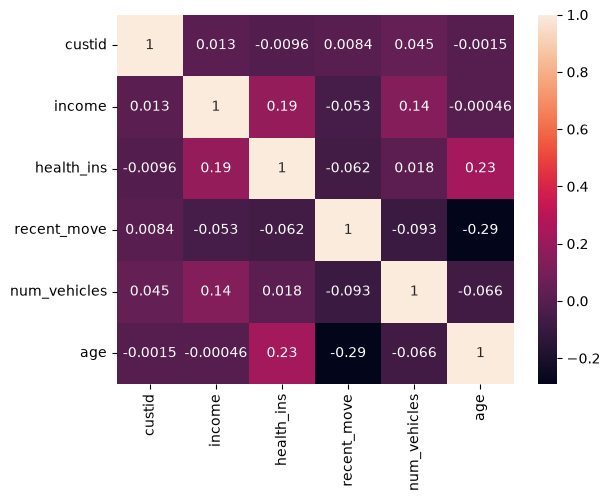

In [9]:
#Seaborn heat map of CLEANED data
sns.heatmap(df_mod.corr(numeric_only=True), annot=True)

In [10]:
#Calculate the 3 way comparison CLEANED data of age, income, number of vehicles using ANOVA

#Fit the model to CLEANED data (df_mod)
model = ols('age ~ income + num_vehicles', data=df_mod).fit()

#Perform ANOVA
anova_result = sm.stats.anova_lm(model, typ=2)

#Print ANOVA result
print("Correlations of Cleaned Data")
print(anova_result)

Correlations of Cleaned Data
                     sum_sq     df         F    PR(>F)
income            20.281540    1.0  0.072749  0.787435
num_vehicles    1152.078100    1.0  4.132434  0.042349
Residual      262340.662746  941.0       NaN       NaN


<Axes: xlabel='age', ylabel='num_vehicles'>

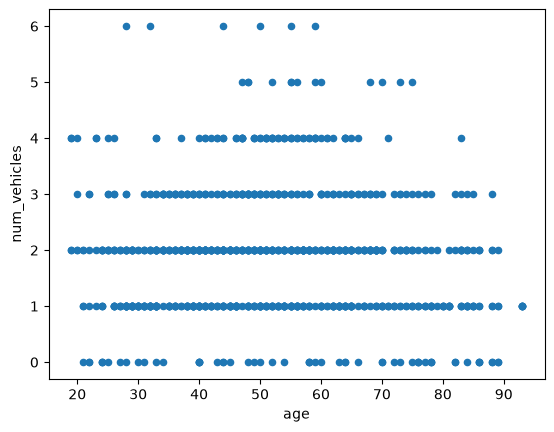

In [11]:
df_mod.plot.scatter(x='age', y='num_vehicles')

# Discussion of the ANOVA results of the cleaned data set

note: I am unsure if you would like the heat map matrix or ANOVA. I chose to discuss ANOVA because it is a three way comparison and I we are supposed to use ANOVA in that case. I added the seaborn heatmaps just in case.

The ANOVA correlation comparison between age, income, and number vehicles resulted a p-values of 0.787435 for income and 0.042349 for number of vehicles. P-values greater that 0.05 do not disprove the null hypothesis, so we find no correlation with income. However, the p-value for number of vehicles is slightly less than 0.05, indicating we reject the null hypothesis and that a correlation exists between age and number of vehicles. The F-value of 4.13, indicates that the effect is above the noise, adding further informaton to the correlation. 

However, if you are asking about correleation coefficients (r-values), the Seaborn heatmap show low r-values for all parameters, including age/income, age/number of vehicles, and income/number of vehicles. The r-values indicate no correlation between and of the two combined parameters using my cleaned data.


https://github.com/acamend/cs82a-portfolio